**Analysis Steps**:
- Import ES trading data and clean ready for merging
- Import S&P E-mini Futures data and clean ready for merging
- Merge ES trading data into Futures data for analysis of daily settlement/returns
- Perform analysis on trading strategy:
    - Mean returns and volatility
    - Correlation/Beta with futures data (determine alpha)
    - Maximum drawdown, hit rate, sharpe ratio, etc. 
    - Plots
- Put together initial summary of findings, ready for "new" strategy investigation.

**1. Import and clean ES Trading Data**:

Import Libraries:

In [41]:
# Import libraries
import pandas as pd 
import numpy as np 
import math 
import statistics 
import matplotlib.pyplot as plt 
import yfinance as yf

File import:

In [42]:
# Import and inspect ES_2020-2025.csv 
raw_df = pd.read_csv(r".\Signal_data\ES_2020-2025.csv", sep=";", engine="python") 

# Remove first row of NaN data
raw_df = raw_df.iloc[1:].reset_index(drop=True) 

# Remove the imported but empty last column 
raw_df = raw_df.iloc[:,:-1]

# Display current header 
raw_df.head() 

,Quarter,Model_Classification_ID,Entry_Date_ISO,ES_Entry_Price,Direction,Exit_Date_ISO,ES_Exit_Price
0,q3-20,q3-20_1,2020-08-10,"3347,00",-1.0,2020-08-11,"3350,25"
1,q3-20,q3-20_2,2020-08-11,"3350,25",1.0,2020-08-19,"3388,75"
2,q3-20,q3-20_3,2020-08-19,"3388,75",-1.0,2020-08-20,"3370,25"
3,q3-20,q3-20_4,2020-08-20,"3370,25",1.0,2020-08-28,"3488,00"
4,q4-20,q4-20_1,2020-09-25,"3243,50",1.0,2020-09-28,"3291,00"


Edit column values and tidy:

In [43]:
# Change column names
columns = ["Quarter", "Model_Classification_ID", "Entry_Date", "Entry_Price", "Signal", "Exit_Date", "Exit_Price"]
raw_df.columns = columns 

# Change prices to floats 
raw_df["Entry_Price"] = raw_df["Entry_Price"].str.replace(",", ".").astype(float) 
raw_df["Exit_Price"] = raw_df["Exit_Price"].str.replace(",", ".").astype(float)

# Change date strings to datetime 
raw_df["Entry_Date"] = pd.to_datetime(raw_df["Entry_Date"])
raw_df["Exit_Date"] = pd.to_datetime(raw_df["Exit_Date"])

# Drop Unnecessary columns
raw_df = raw_df.drop(columns=["Quarter", "Model_Classification_ID"])

# Review data formatting
raw_df.info()

# Rename trade data
trade_df = raw_df.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Entry_Date   117 non-null    datetime64[ns]
 1   Entry_Price  117 non-null    float64       
 2   Signal       117 non-null    float64       
 3   Exit_Date    117 non-null    datetime64[ns]
 4   Exit_Price   117 non-null    float64       
dtypes: datetime64[ns](2), float64(3)
memory usage: 4.7 KB


Review final trade data:

In [44]:
# Review final trade data
trade_df.head()

,Entry_Date,Entry_Price,Signal,Exit_Date,Exit_Price
0,2020-08-10,3347.00,-1.0,2020-08-11,3350.25
1,2020-08-11,3350.25,1.0,2020-08-19,3388.75
2,2020-08-19,3388.75,-1.0,2020-08-20,3370.25
3,2020-08-20,3370.25,1.0,2020-08-28,3488.00
4,2020-09-25,3243.50,1.0,2020-09-28,3291.00


**2. Import and clean E-Mini Futures Data**

Market Data import:

In [45]:
# Comment out and pull from CSV 
#ES_df = yf.download("ES=F", start=trade_df["Entry_Date"].iloc[0], end=trade_df["Exit_Date"].iloc[-1], auto_adjust=False) 
#ES_df.columns = ES_df.columns.droplevel(1)
#ES_df.reset_index().to_csv(r".\Market_data\ES_daily.csv", index=False)
#print(ES_df)

Import market data from csv:

In [46]:
# Import data
ES_df = pd.read_csv(
    r".\Market_data\ES_daily.csv",
    index_col=0,
    parse_dates=True
)

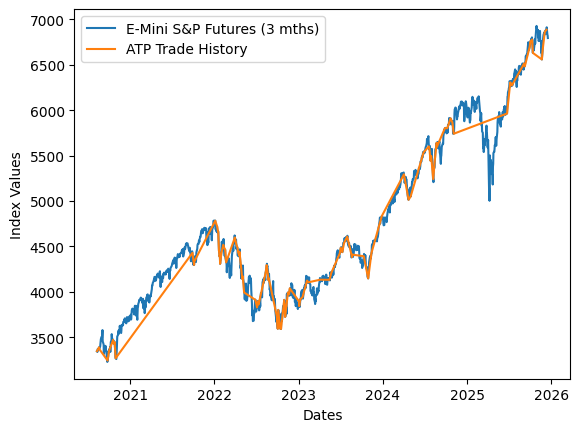

In [47]:
# Plot results to check merging
plt.plot(ES_df.index, ES_df.Open, label="E-Mini S&P Futures (3 mths)")
plt.plot(trade_df.Entry_Date, trade_df.Entry_Price, label="ATP Trade History")
plt.xlabel("Dates") 
plt.ylabel("Index Values")
plt.legend()
plt.show()

**3. Merge Trading and Market Data for Analysis**:

In [56]:
# Create new Trading Strategy Dataframe
TS_df = ES_df.copy() 
TS_df.index = pd.to_datetime(TS_df.index)

In [58]:
# Add signal column
TS_df["Signal"] = 0 

# Fill trade signals over from trade data
for _, row in trade_df.iterrows():
    TS_df.loc[(TS_df.index >= row["Entry_Date"]) & (TS_df.index < row["Exit_Date"]), "Signal"] = row["Signal"]

In [61]:
TS_df.head(10)

,Adj Close,Close,High,Low,Open,Volume,Signal
Date,,,,,,,
2020-08-10,3352.75,3352.75,3357.25,3329.00,3347.00,1201751,-1
2020-08-11,3330.00,3330.00,3379.00,3319.50,3350.25,1733040,1
2020-08-12,3370.00,3370.00,3382.50,3326.25,3339.50,1408718,1
2020-08-13,3367.75,3367.75,3382.00,3357.50,3367.75,1205758,1
2020-08-14,3361.50,3361.50,3380.50,3350.00,3369.25,1084771,1
2020-08-17,3379.75,3379.75,3382.75,3364.75,3366.00,759304,1
2020-08-18,3387.00,3387.00,3390.75,3365.25,3379.25,1019552,1
2020-08-19,3372.75,3372.75,3395.75,3365.50,3388.75,1368420,-1
2020-08-20,3380.75,3380.75,3387.00,3344.75,3370.25,1203334,1


In [60]:
trade_df.head()

,Entry_Date,Entry_Price,Signal,Exit_Date,Exit_Price
0,2020-08-10,3347.00,-1.0,2020-08-11,3350.25
1,2020-08-11,3350.25,1.0,2020-08-19,3388.75
2,2020-08-19,3388.75,-1.0,2020-08-20,3370.25
3,2020-08-20,3370.25,1.0,2020-08-28,3488.00
4,2020-09-25,3243.50,1.0,2020-09-28,3291.00
